# Intent Parsing & Classification with Local LLMs

This notebook implements an intent classifier using **`instructor`** — the standard library for structured extraction from LLMs.

**Improvements over the base implementation:**
- `instructor` replaces manual JSON parsing → cleaner and more robust
- Automatic retries if the LLM returns an incorrect format
- Built-in data validation via Pydantic v2
- Support for multiple backends: Ollama, OpenAI, Anthropic

**Stack:**
```
instructor  →  handles the prompt ↔ Pydantic validation cycle
pydantic    →  defines and validates the output structure
openai      →  HTTP client (compatible with Ollama/LM Studio)
```

## 1. Installation

In [1]:
#%pip install -q instructor openai pydantic

## 2. Imports

In [2]:
from __future__ import annotations

from typing import Optional

import instructor
from openai import OpenAI
from pydantic import BaseModel, Field, field_validator

## 3. Output Schema (Pydantic)

`intent` is a free `str`: the LLM infers and names the intent on its own, without being constrained to a predefined list. The field description guides the expected format (PascalCase, verb + noun) without restricting it.

The `field_validator` on `confidence` ensures the LLM does not return out-of-range values — if it does, Pydantic raises an error that `instructor` uses to automatically request a correction.

In [3]:
class ParsedIntent(BaseModel):
    """Structured result of the analysis of a user query."""

    intent: str = Field(
        description=(
            "Primary detected intent. Use PascalCase and be specific, "
            "e.g. 'SearchProduct', 'RequestQuote', 'TrackOrder'. "
            "If it does not fit any known category, invent a descriptive name."
        )
    )
    product_name: Optional[str] = Field(
        default=None,
        description="Name of the product mentioned, if any. None if not applicable."
    )
    quantity: Optional[int] = Field(
        default=None,
        description="Requested quantity, if explicitly mentioned."
    )
    confidence: float = Field(
        description="Confidence level in the classification, between 0.0 and 1.0."
    )
    reasoning: str = Field(
        description="Brief explanation of why that intent was chosen."
    )

    @field_validator("confidence")
    @classmethod
    def confidence_in_range(cls, v: float) -> float:
        if not 0.0 <= v <= 1.0:
            raise ValueError(f"confidence must be between 0 and 1, got: {v}")
        return round(v, 2)

## 4. Client Configuration

`instructor.from_openai()` wraps the client with the logic to:
1. Inject the Pydantic JSON schema into the prompt
2. Parse the response
3. Automatically retry if validation fails (up to 3 attempts by default)

The OpenAI client points to Ollama locally — just change `base_url` to use another backend.

In [4]:
# --- Ollama (local) ---
raw_client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="qwen3",  # Ollama does not require an API key, but the client asks for one
)

# --- OpenAI (cloud) — uncomment and change base_url if you prefer ---
# raw_client = OpenAI(api_key="sk-...")

# instructor wraps the client adding structured validation
client = instructor.from_openai(raw_client, mode=instructor.Mode.JSON)

MODEL = "qwen3:8b"  # Change to the model you have available in Ollama

## 5. Intent Classifier

The class is minimal — `instructor` handles the entire parsing/validation/retry cycle.
The system prompt gives the model domain context.

In [5]:
SYSTEM_PROMPT = """
You are an intent classifier for a procurement system based on the Beckn protocol.
Analyze the user's query and return the most precise intent.

Domain context:
- Users search for industrial products, equipment, and materials
- They may request quotes (RFQ), place orders, or track purchases
- Suppliers are on a decentralized Beckn network
""".strip()


class IntentClassifier:
    def __init__(self, model: str = MODEL, max_retries: int = 3):
        self.model = model
        self.max_retries = max_retries

    def classify(self, query: str) -> ParsedIntent:
        """Classifies the intent of a user query."""
        return client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": query},
            ],
            response_model=ParsedIntent,   # instructor uses this to parse and validate
            max_retries=self.max_retries,
        )

## 6. Tests with Examples

In [6]:
classifier = IntentClassifier()

test_queries = [
    "I need 500 units of 2-inch stainless steel valves",
    "How much does the AC-200 air compressor model cost?",
    "I want to cancel order PO-2024-0892",
    "What is the status of my M8 bolt order?",
    "Do you have HEPA H14 filters in stock?",
    "I need a quote for 10 Dell Latitude laptops",
    "Good morning",
]

for query in test_queries:
    result = classifier.classify(query)
    print(f"Query     : {query}")
    print(f"Intent    : {result.intent}")
    print(f"Product   : {result.product_name or '—'}")
    print(f"Quantity  : {result.quantity or '—'}")
    print(f"Confidence: {result.confidence:.0%}")
    print(f"Reason    : {result.reasoning}")
    print("-" * 60)

Query     : I need 500 units of 2-inch stainless steel valves
Intent    : RequestQuote
Product   : 2-inch stainless steel valves
Quantity  : 500
Confidence: 95%
Reason    : The user explicitly states their need for a specific quantity and product variant, which aligns with the RequestQuote intent in procurement processes. The mention of quantity and detailed product specifications indicates they are seeking quotes for purchase.
------------------------------------------------------------
Query     : How much does the AC-200 air compressor model cost?
Intent    : RequestQuote
Product   : AC-200 air compressor model
Quantity  : —
Confidence: 95%
Reason    : The user is specifically asking about the cost of a product, which aligns with the RequestQuote intent in procurement systems. The query focuses on pricing information rather than general product search or order tracking.
------------------------------------------------------------
Query     : I want to cancel order PO-2024-0892
Inten

## 7. Batch Processing

For high query volumes: process in parallel with `ThreadPoolExecutor`.
The result is a pandas DataFrame for immediate analysis.

In [7]:
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd


def classify_batch(queries: list[str], max_workers: int = 4) -> pd.DataFrame:
    """Classifies multiple queries in parallel and returns a DataFrame."""
    results = {}

    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {pool.submit(classifier.classify, q): q for q in queries}

        for future in as_completed(futures):
            query = futures[future]
            try:
                r = future.result()
                results[query] = {
                    "intent":       r.intent,
                    "product_name": r.product_name,
                    "quantity":     r.quantity,
                    "confidence":   r.confidence,
                    "reasoning":    r.reasoning,
                    "error":        None,
                }
            except Exception as e:
                results[query] = {"intent": None, "error": str(e)}

    df = pd.DataFrame.from_dict(results, orient="index")
    df.index.name = "query"
    return df


df = classify_batch(test_queries)
df

,intent,product_name,quantity,confidence,reasoning,error
query,,,,,,
I need 500 units of 2-inch stainless steel valves,RequestQuote,2-inch stainless steel valves,500.0,0.95,The user explicitly states their need for a sp...,None
How much does the AC-200 air compressor model cost?,RequestQuote,AC-200 air compressor model,NaN,0.95,The query explicitly asks about the cost of a ...,None
What is the status of my M8 bolt order?,TrackOrder,M8 bolt,NaN,0.95,The query explicitly asks about the status of ...,None
I want to cancel order PO-2024-0892,CancelOrder,NaN,NaN,0.95,The user explicitly mentions canceling an orde...,None
Do you have HEPA H14 filters in stock?,CheckStock,HEPA H14 filters,NaN,0.95,The query specifically asks about product avai...,None
I need a quote for 10 Dell Latitude laptops,RequestQuote,Dell Latitude laptops,10.0,0.95,The query explicitly mentions 'need a quote' a...,None
Good morning,GreetUser,NaN,NaN,0.80,The message contains a standard greeting witho...,None


## 8. Distribution of Detected Intents

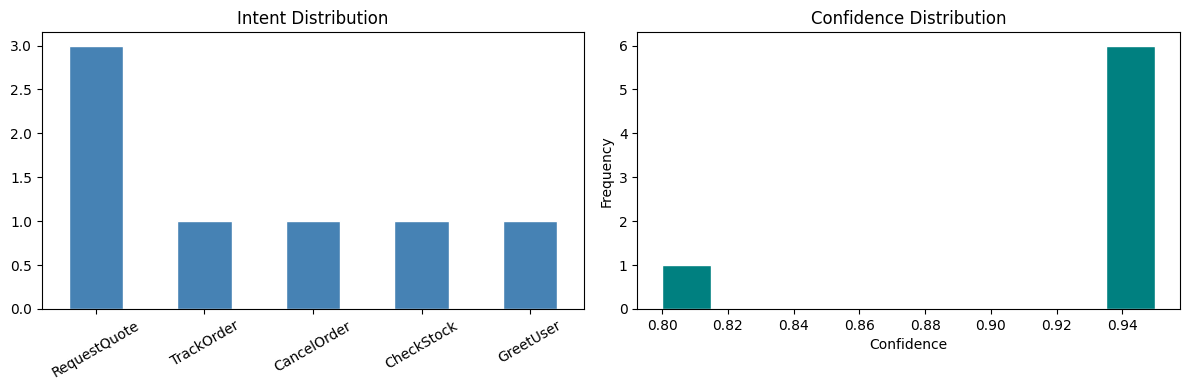

In [8]:
import matplotlib.pyplot as plt

counts = df["intent"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Intent bars
counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Intent Distribution")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

# Confidence distribution
df["confidence"].dropna().plot(kind="hist", ax=axes[1], bins=10, color="teal", edgecolor="white")
axes[1].set_title("Confidence Distribution")
axes[1].set_xlabel("Confidence")

plt.tight_layout()
plt.show()

## 9. Using Anthropic Claude Instead of Ollama

`instructor` supports the Anthropic SDK natively — same `ParsedIntent` class, same classifier, only the client changes.

In [9]:
# %pip install -q anthropic

# import anthropic

# anthropic_client = instructor.from_anthropic(
#     anthropic.Anthropic(api_key="sk-ant-...")  # or use ANTHROPIC_API_KEY in the environment
# )

# result = anthropic_client.messages.create(
#     model="claude-sonnet-4-6",
#     max_tokens=512,
#     messages=[{"role": "user", "content": "I need 50 electric motors of 5HP"}],
#     response_model=ParsedIntent,
# )
# print(result.model_dump_json(indent=2))

## Summary

| Aspect | Base implementation | This notebook |
|---|---|---|
| Parsing | Manual `json.loads()` | Automatic `instructor` |
| Retries | None | Automatic (up to `max_retries`) |
| Intents | Fixed `Literal[...]` | Free `str` — the LLM infers them |
| Fields | 3 | 5 (+ `quantity`, `reasoning`) |
| Validation | Pydantic types only | + `field_validator` on confidence |
| Batch | No | `ThreadPoolExecutor` + DataFrame |
| Backends | Ollama | Ollama, OpenAI, Anthropic |

## 10. Beckn Procurement Intent Parser

Extends the base classifier with a full Beckn-aligned extraction pipeline:

| Component | Role |
|---|---|
| `resolve_location` | Maps city names to lat/lon coordinates |
| `is_complex_request` | Heuristic router — selects model by query complexity |
| `BecknIntent` | Structured Pydantic model for Beckn procurement fields |
| `BecknIntentParser` | Extracts `BecknIntent` using the complexity-selected model |
| `parse_procurement_request` | Unified pipeline: classify intent → route → extract |

In [10]:
_CITY_COORDINATES: dict[str, str] = {
    "bangalore":  "12.9716,77.5946",
    "bengaluru":  "12.9716,77.5946",
    "mumbai":     "19.0760,72.8777",
    "delhi":      "28.7041,77.1025",
    "new delhi":  "28.6139,77.2090",
    "chennai":    "13.0827,80.2707",
    "hyderabad":  "17.3850,78.4867",
    "pune":       "18.5204,73.8567",
    "kolkata":    "22.5726,88.3639",
}


def resolve_location(text: str) -> str:
    normalized = text.strip().lower()
    for city, coords in _CITY_COORDINATES.items():
        if city in normalized:
            return coords
    return text

In [11]:
import re

_DELIVERY_KEYWORDS = frozenset({
    "delivery", "deliver", "timeline", "deadline",
    "days", "weeks", "hours", "within",
})
_BUDGET_KEYWORDS = frozenset({
    "budget", "price", "cost", "rupee", "rupees",
    "inr", "usd", "per unit", "per sheet", "per meter",
    "under", "maximum", "max",
})


def is_complex_request(query: str) -> bool:
    if len(query) > 120:
        return True
    if len(re.findall(r"\b\d+(?:\.\d+)?\b", query)) >= 2:
        return True
    lower = query.lower()
    if any(kw in lower for kw in _DELIVERY_KEYWORDS):
        return True
    if any(kw in lower for kw in _BUDGET_KEYWORDS):
        return True
    return False

In [12]:
class BudgetConstraints(BaseModel):
    max: float
    min: float = 0.0


class BecknIntent(BaseModel):
    item: str = Field(description="Product name")
    descriptions: list[str] = Field(
        description="Technical specs extracted from the query, e.g. ['80gsm', 'A4', 'Cat6']"
    )
    quantity: int = Field(description="Quantity requested")
    location_coordinates: str = Field(
        description=(
            "Location as 'lat,lon'. Resolve known Indian cities to their coordinates "
            "using the provided lookup. Return raw text if unknown."
        )
    )
    delivery_timeline: int = Field(
        description="Delivery time in hours. Convert: 1 day = 24h, 1 week = 168h."
    )
    budget_constraints: BudgetConstraints = Field(
        description="Budget limits. If only an upper bound is given, set max to that and min to 0."
    )

    @field_validator("delivery_timeline")
    @classmethod
    def timeline_positive(cls, v: int) -> int:
        if v <= 0:
            raise ValueError(f"delivery_timeline must be > 0, got {v}")
        return v

    @field_validator("location_coordinates")
    @classmethod
    def apply_location_lookup(cls, v: str) -> str:
        return resolve_location(v)

In [13]:
_BECKN_SYSTEM_PROMPT = """
You are a procurement data extractor for the Beckn protocol.
Extract structured data from the user query.

Rules:
- Extract all technical specs into descriptions (e.g. "80gsm", "A4", "Cat6", "2 inch")
- Convert all time expressions to hours: 1 day = 24h, 1 week = 168h
- Use only numeric values for budget fields (no currency symbols)
- Resolve locations using this lookup:
  Bangalore/Bengaluru=12.9716,77.5946 | Mumbai=19.0760,72.8777 | Delhi=28.7041,77.1025
  Chennai=13.0827,80.2707 | Hyderabad=17.3850,78.4867 | Pune=18.5204,73.8567
  Kolkata=22.5726,88.3639
- If location is not in the list, return the raw location text
- If only an upper budget is mentioned, set min to 0
""".strip()


class BecknIntentParser:
    def __init__(
        self,
        complex_model: str = "qwen3:8b",
        simple_model: str = "qwen3:1.7b",
    ):
        self.complex_model = complex_model
        self.simple_model = simple_model
        self.last_model_used: str = complex_model

    def _select_model(self, query: str) -> str:
        return self.complex_model if is_complex_request(query) else self.simple_model

    def parse(self, query: str) -> BecknIntent:
        model = self._select_model(query)
        messages = [
            {"role": "system", "content": _BECKN_SYSTEM_PROMPT},
            {"role": "user", "content": query},
        ]
        try:
            result = client.chat.completions.create(
                model=model,
                messages=messages,
                response_model=BecknIntent,
                max_retries=3,
            )
            self.last_model_used = model
            return result
        except Exception:
            if model != self.complex_model:
                result = client.chat.completions.create(
                    model=self.complex_model,
                    messages=messages,
                    response_model=BecknIntent,
                    max_retries=3,
                )
                self.last_model_used = self.complex_model
                return result
            raise

In [14]:
_PROCUREMENT_INTENTS = {"SearchProduct", "RequestQuote", "PurchaseOrder"}

_intent_classifier = IntentClassifier()
_beckn_parser = BecknIntentParser()


def parse_procurement_request(query: str) -> dict:
    intent_result = _intent_classifier.classify(query)

    if intent_result.intent not in _PROCUREMENT_INTENTS:
        return {
            "intent": intent_result.intent,
            "beckn_intent": None,
            "routed_to": None,
        }

    beckn_result = _beckn_parser.parse(query)
    return {
        "intent": intent_result.intent,
        "beckn_intent": beckn_result.model_dump(),
        "routed_to": _beckn_parser.last_model_used,
        "confidence": intent_result.confidence,
    }

In [15]:
import json

_test_queries = [
    "I need 500 units of A4 printer paper 80gsm delivered to our Bangalore office within 5 days, budget under 2 rupees per sheet",
    "I need 200 meters of UTP Cat6 cable for an office in Mumbai, delivery in 3 days, maximum budget 15 rupees per meter",
    "Good morning, can you help me?",
]

for query in _test_queries:
    print(f"Query: {query}")
    result = parse_procurement_request(query)
    print(json.dumps(result, indent=2, default=str))
    print("-" * 60)

Query: I need 500 units of A4 printer paper 80gsm delivered to our Bangalore office within 5 days, budget under 2 rupees per sheet
{
  "intent": "RequestQuote",
  "beckn_intent": {
    "item": "A4 printer paper",
    "descriptions": [
      "80gsm",
      "A4"
    ],
    "quantity": 500,
    "location_coordinates": "12.9716,77.5946",
    "delivery_timeline": 120,
    "budget_constraints": {
      "max": 1000.0,
      "min": 0.0
    }
  },
  "routed_to": "qwen3:8b",
  "confidence": 0.95
}
------------------------------------------------------------
Query: I need 200 meters of UTP Cat6 cable for an office in Mumbai, delivery in 3 days, maximum budget 15 rupees per meter
{
  "intent": "RequestQuote",
  "beckn_intent": {
    "item": "UTP Cat6 cable",
    "descriptions": [
      "200 meters",
      "UTP Cat6"
    ],
    "quantity": 1,
    "location_coordinates": "19.0760,72.8777",
    "delivery_timeline": 72,
    "budget_constraints": {
      "max": 3000.0,
      "min": 0.0
    }
  },
  "ro